# Exploratory Data Analysis on a Dataset (EDA)

### **1. Data Cleaning and Preparation:**

In [205]:
# Import all necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [206]:
#Load the Dataset
df=pd.read_csv('Cardiotocographic.csv')

In [207]:
# Size of Dataset
df.shape

(2126, 14)

### Dataset Size 
The data set contains 2126 rows and 14 columns.

In [208]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


### Data Information Observation
* **Data Types:** All 14 columns are stored as float numbers (`float64`). There are no text columns or incorrect data types in the raw dataset.
* **Missing Values:** Columns like `LB`, `AC`, `DS`, `DP`, `MLTV`, `Width`, `Tendency`, and `NSP` have missing entries because their counts are lower than 2,126. 


In [218]:
# first 5 rows of data
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [212]:
# Missing Values
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [214]:
### Total Missing values
df.isnull().sum().sum()

np.int64(167)

### Total Missing Values
The dataset  contains total 167 missing values.

In [215]:
# Drop missing values (we have almost 1% of data missing so we drop those rows, it won't affect the data info)
df.dropna(inplace=True)

In [219]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

### Missing Values Cleaned
After dropping missing values, the dataset contains no missing values

In [220]:
#Check the new size
df.shape

(2105, 14)

### New Dataset Size
After dropping missing values, the size of data is (2105, 14).

In [171]:
# Check the Duplicates
df.duplicated().sum()

np.int64(2)

The dataset contains 2 duplicate rows.

In [172]:
# Duplicate rows
df[df.duplicated()]

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
1115,122.0,0.000000,0.0,0.000000,0.0,0.0,0.0,19.0,1.9,0.0,15.1,39.0,0.0,1.0
1458,148.0,0.004717,0.0,0.002358,0.0,0.0,0.0,40.0,0.9,0.0,10.6,35.0,0.0,1.0


In [173]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [174]:
df.duplicated().sum()

np.int64(0)

### Duplicate Rows dropped
After droping duplicates we have no duplicate rows

In [175]:
# Separate the target column and feature columns 
target = df['NSP']
features = df.drop(columns=['NSP'])

In [221]:
print(target.shape)
print(features.shape)

(2103,)
(2103, 13)


In [176]:
target.head()

0    2.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: NSP, dtype: float64

In [177]:
features.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000


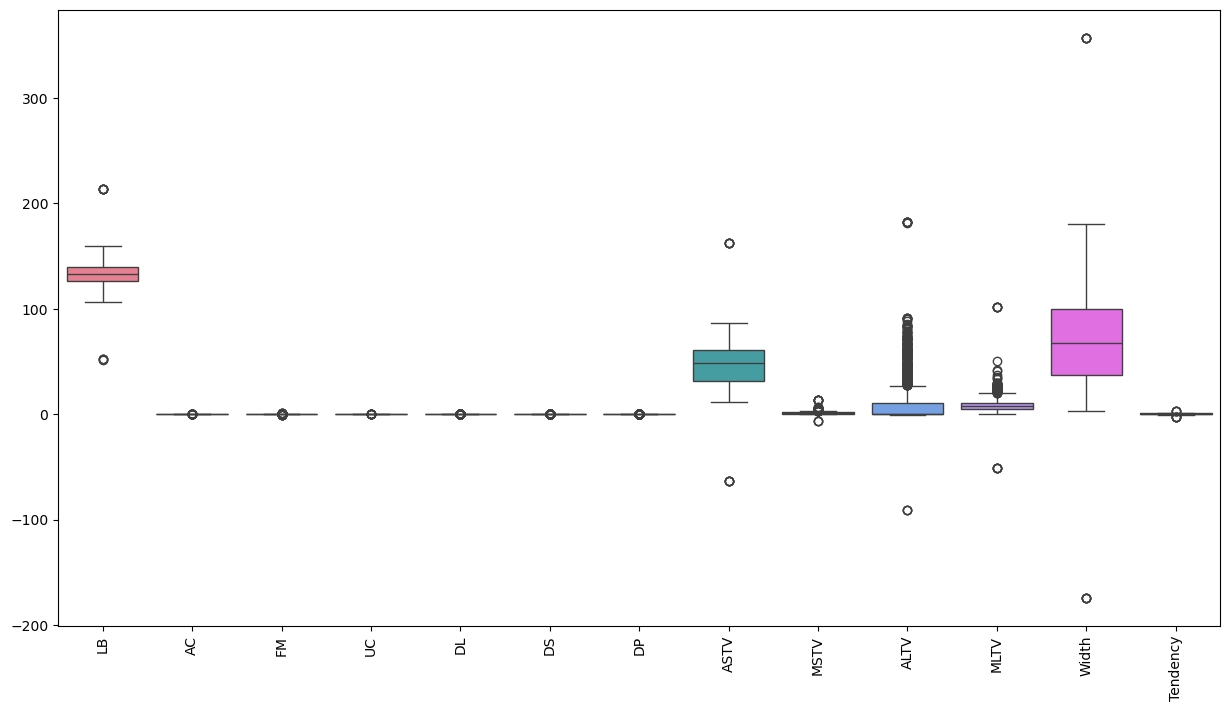

In [178]:
# Check the outliers by using box plot
plt.figure(figsize=(15,8))
sns.boxplot(features)
plt.xticks(rotation=90)
plt.show()

### Outlier Observation
from the above box plot we can find outliers for all feature column, to remove outliers we do capping

In [179]:
#### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

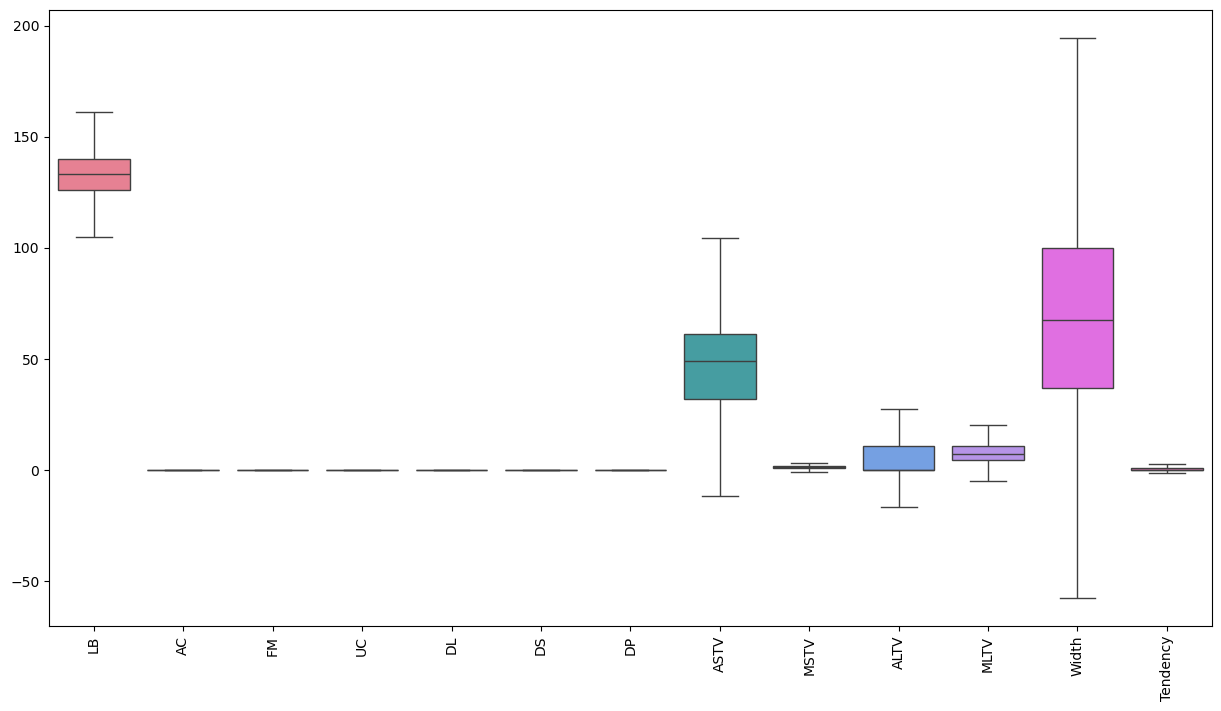

In [180]:
# Outlier Check
plt.figure(figsize=(15,8))
sns.boxplot(features)
plt.xticks(rotation=90)
plt.show()

### Outliers Removed
After capping we don't have outliers, in the above box plot we can see the outliers are treated using IQR-based capping

### Data Preparation Summary
The dataset was successfully cleaned and prepared for analysis. Missing values were handled using row deletion, duplicate records were removed, data types were verified, and outliers were treated using IQR-based capping. The cleaned dataset is now ready for statistical analysis and visualization.


### **2. Statistical Summary:**

In [224]:
# Stats Summary 
features.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
count,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000,2103.0,2103.0,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000,2103.000000
mean,133.291604,0.003144,0.001565,0.004361,0.001770,0.0,0.0,46.999304,1.301912,6.733464,8.017610,70.351685,0.319999
std,9.976211,0.003844,0.002477,0.003008,0.002675,0.0,0.0,17.633594,0.779896,10.400402,5.094192,39.773195,0.624916
min,105.000000,-0.008475,-0.003839,-0.005219,-0.004942,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.850000,-57.500000,-1.500000
25%,126.000000,0.000000,0.000000,0.001838,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000
50%,133.000000,0.001631,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.486468,0.000000
75%,140.000000,0.005650,0.002559,0.006543,0.003295,0.0,0.0,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000
max,161.000000,0.014124,0.006398,0.013601,0.008237,0.0,0.0,104.500000,3.200000,27.500000,20.350000,194.500000,2.500000


#### Insights from the Data
* The average baseline fetal heart rate (LB) is around 133 bpm, and most values are close to this range.
* Accelerations (AC) are generally low for most observations.
* Fetal movements (FM) are zero in many records, showing that movement was not detected frequently.
* Uterine contractions (UC) have relatively small values and do not vary much.
* ASTV values vary a lot from one record to another, showing differences in fetal heart rate patterns.
* ALTV is zero for many records, but a few records have high values.
* MLTV shows moderate variation across the dataset.
* The Width feature has a wide range of values, indicating differences in fetal heart rate distributions.
* Most Tendency values are close to zero, suggesting stable heart rate trends in many cases.
* Some features contain very high or very low values, showing that fetal conditions vary across different cases.


### **3. Data Visualization:**

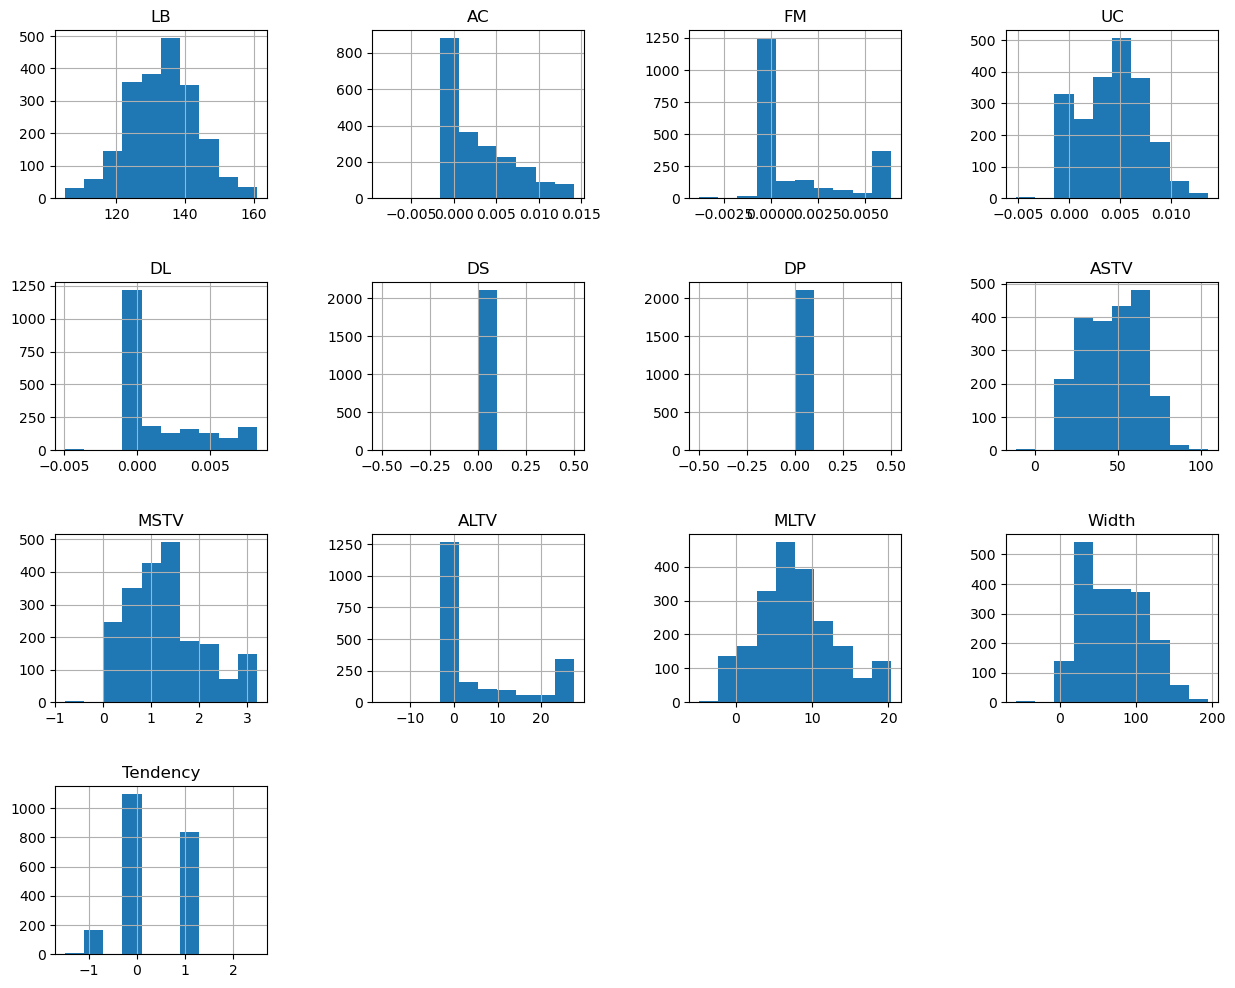

In [225]:
# Histogram
features.hist(figsize=(15,12))
plt.subplots_adjust(hspace=0.5,wspace=0.5)     
plt.show()

### Histogram Observations

* **Different Shapes:** Most features show different patterns of distribution, indicating variation in fetal health measurements.
* **Wide Spreads:** Features such as LB, ASTV, Width, and MLTV have values spread over a wider range.
* **Clustered Near Zero:** Features like AC, FM, UC, DL, DS, and DP have most of their values clustered near 0, showing that these measurements occur at low levels in many records.
* **Low Values:** ALTV and FM have mostly low values with only a few higher values appearing across the data.


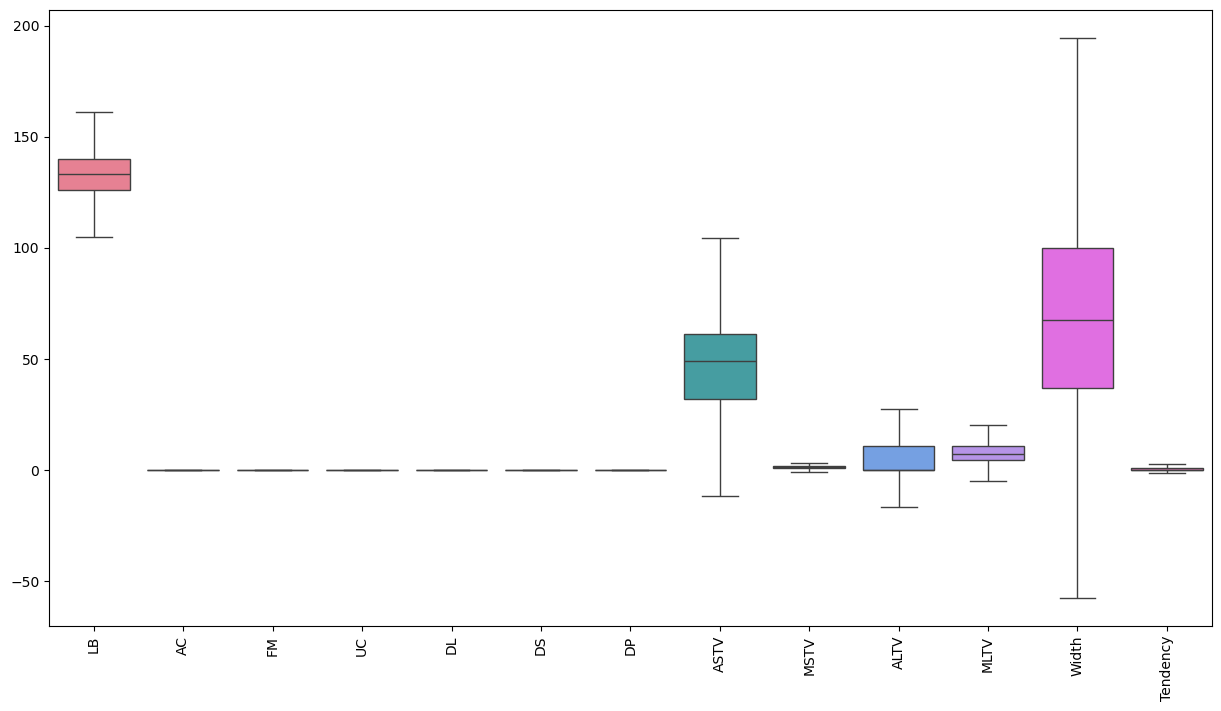

In [226]:
# Box Plot
plt.figure(figsize=(15,8))
sns.boxplot(data=features)
plt.xticks(rotation=90)
plt.show()

### Observation
* LB values are mostly concentrated between 125 and 140.
* ASTV and Width show a wider spread compared to other features, indicating greater variability.
* AC, FM, UC, DL, DS, and DP have very small values and are concentrated close to 0.
* ALTV and MLTV show moderate variation among the observations.
* The median values differ across features, indicating differences in their distributions.

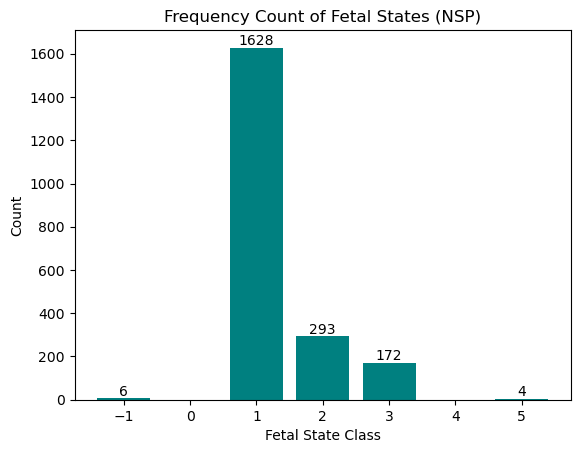

In [184]:
### Bar Chart
counts = df['NSP'].round().value_counts()
bars = plt.bar(counts.index,counts.values,color='#008080')
plt.title('Frequency Count of Fetal States (NSP)')
plt.xlabel('Fetal State Class')
plt.ylabel('Count')
plt.bar_label(bars)
plt.show()


### Bar Chart Observations

* **Healthy Cases (1):** The tallest bar shows that 1,628 fetuses are completely Normal. This makes up the largest part of the dataset by far.
* **Warning Cases (2):** There are 293 Suspect cases, which means doctors might want to monitor them a bit more closely.
* **Danger Cases (3):** There are 172 Pathologic cases, meaning these fetuses are showing signs of distress.
* **Data Errors (-1 and 5):** The graph highlights small mistakes in the data. There are 6 cases listed as -1 and 4 cases listed as 5.


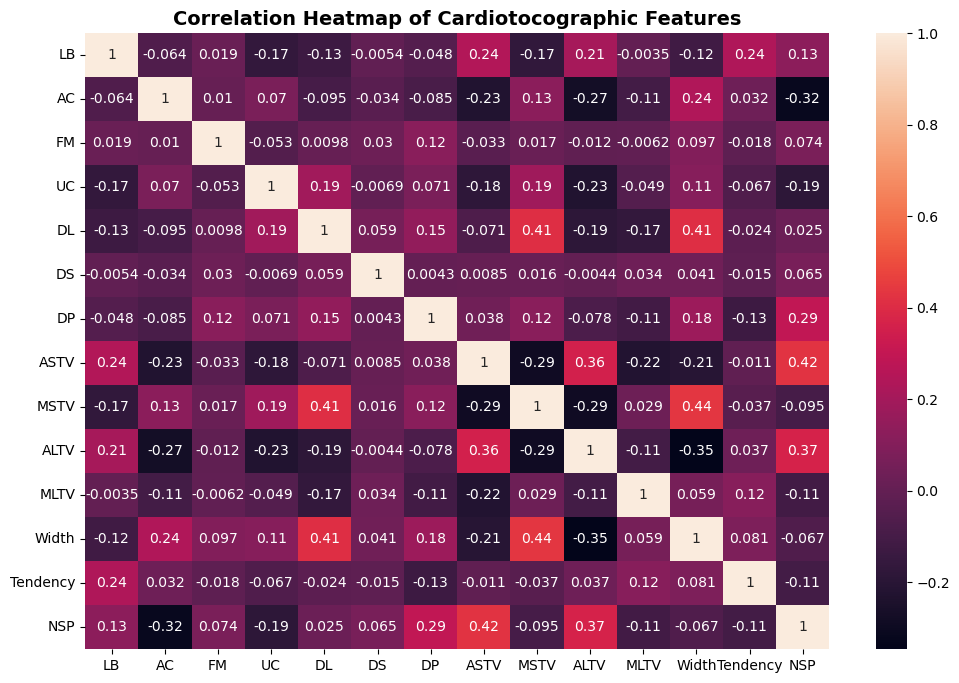

In [227]:
### Heatmap
corr=df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr,annot=True)
plt.title('Correlation Heatmap of Cardiotocographic Features', fontsize=14, fontweight='bold')
plt.show()

### Observations

* **The strongest warning sign (ASTV = 0.42):** This number connects abnormal heart changes to the target (NSP). A high positive number means that when the percentage of abnormal short-term heart variations goes high, the risk score also increases.
* **The best sign of a healthy fetus (AC = -0.32):** This number connects heart speed-ups to the target (NSP). Because it is a negative number, it means they move in opposite directions. More heart speed-ups relate to a lower, safer risk score, confirming that active movement aligns with good health.
* **Other critical danger signals (ALTV = 0.37 and DP = 0.29):** Both abnormal long-term heart variability (ALTV) and prolonged heart rate drops (DP) show clear positive connections to the target. This indicates that long drops or uncharacteristic long-term heart patterns serve as indicators of distress.


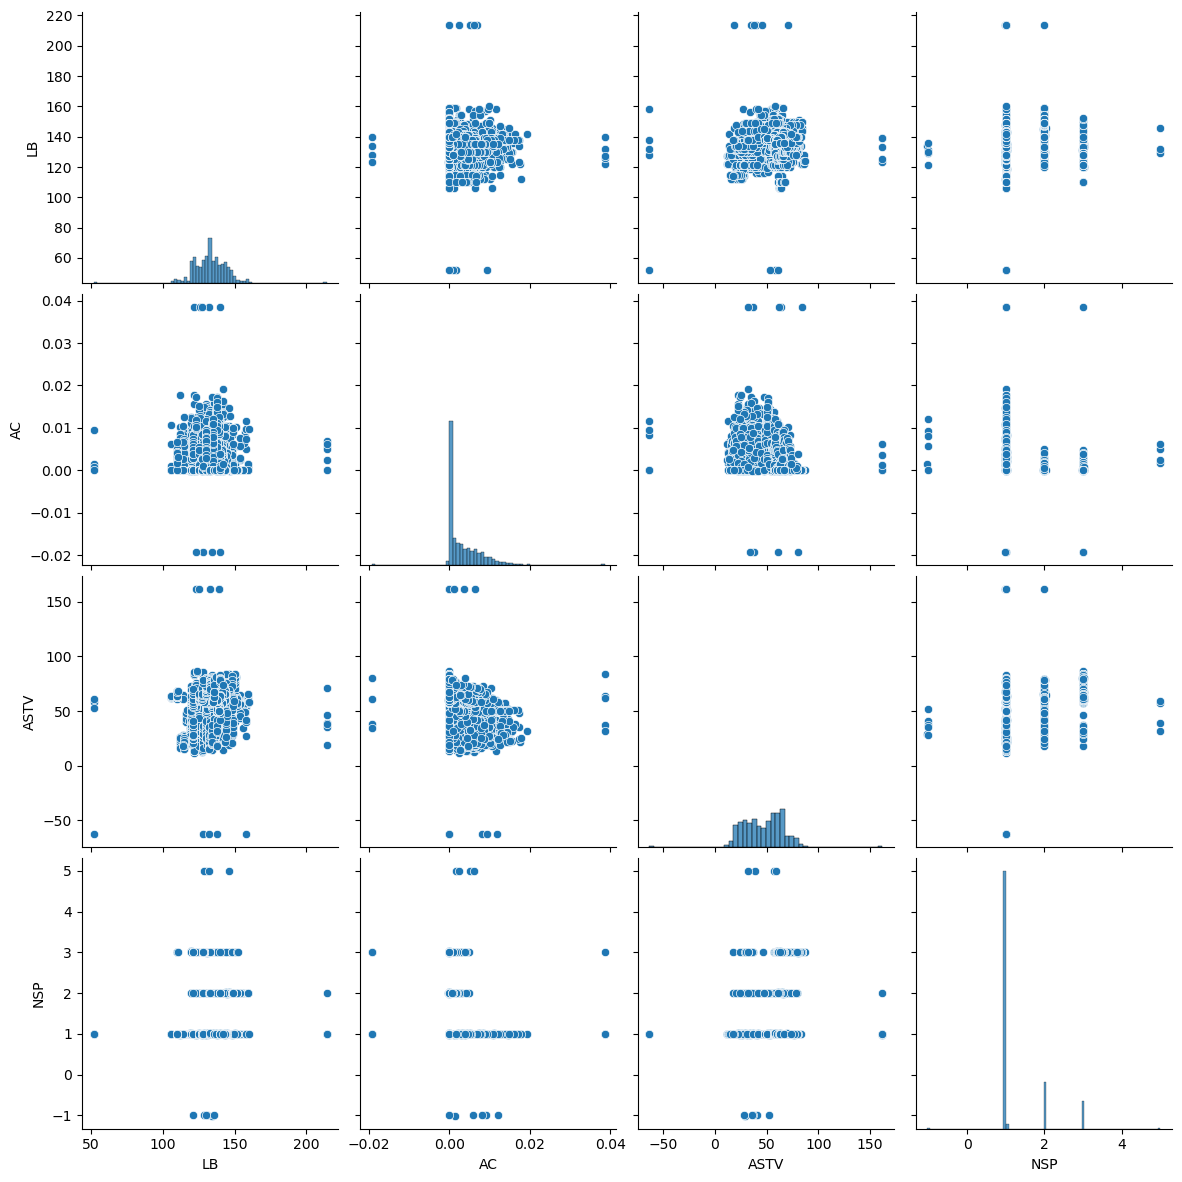

In [195]:
#Pairplot
sns.pairplot(df[['LB', 'AC', 'ASTV', 'NSP']], height=3.0, aspect=1)
plt.show()

### 4.	Pattern Recognition and Insights:
* The link between AC and ASTV: When AC is high, the ASTV stays low. In this case, the fetus is generally safe and healthy.
* The link between ASTV and NSP: When ASTV goes high, the target risk score NSP also goes high. This means that bad heart fluctuations are a clear sign of danger.
* The link between DP and NSP: When DP is high, the target risk score NSP increases. This shows that long drops in heart speed mean the fetus is in distress.
* The  meaning of these patterns: Medical staff can watch these numbers together to catch problems early. If AC drops while ASTV and DP go high, it means the fetus needs quick medical help.

##### Analysis of trends over time: 
The dataset does not have any dates, times, or clock markers. Because there is no time information in the file, it is impossible to see how the heart rate changes over hours or days. The data only shows a single snapshot for each patient record.

## 5.	Conclusion:

#### Key Insights Discovered
* **The main pattern found:** When AC is high, the ASTV stays low. In this case, the fetus is generally safe and healthy.
* **The biggest warning signs:** When ASTV and DP go high, the target risk score NSP also goes high. This shows that the fetus is in danger and needs medical help right away.
* **The balance of the data:** The dataset is very unequal. The normal group is much larger than the suspect and danger groups. There are also a few clear mistakes in the data, like scores showing up at -1 and 5.
* **How this helps choices in the future:** This study shows exactly which measurements are the most important to watch. If a computer model is built later, it must look closely at ASTV, AC, and DP to correctly guess health risks.

#### Impact on Further Analyses and Decision-Making
* **Helping medical decisions:** These findings show doctors exactly which signs to watch closely. By tracking when AC drops and ASTV or DP go high, medical staff can make faster, safer decisions to help a fetus in danger.
* **Fixing data mistakes first:** Before doing any more work, analysts must clean out the incorrect -1 and 5 scores from the NSP column so these errors do not ruin future results.
* **Handling unequal groups:** Because the "Normal" group is so much larger than the others, any future computer model will be biased. Analysts must use special balancing tricks so the model learns how to spot the rare danger cases correctly.
* **Choosing the best features:** Future analysis should focus heavily on ASTV, AC, and DP. Since these features have the strongest links to the target, they will be the most useful tools for building accurate prediction models.